# LR Communication Visualizations (CID44971)
Plots generated from `results/CID44971/lr_scores.csv` and `results/CID44971/lr_communication.csv`; figures are saved to `results/CID44971/figures`.


Data columns (assumptions):
- `lr_scores.csv`: spot_i, spot_j, cell_i, cell_j, ligand, receptor, comm_score, in_knn, distance
- `lr_communication.csv`: src_spot_barcode, dst_spot_barcode, source_cell, target_cell, lr_pair, original_lr_score, attention_score
- We derive LR pair stats, spot in/out degree, degree-scaled attention, and optional spatial overlays.


In [1]:
# If dependencies are missing, uncomment the next line (requires internet)
# %pip install pandas matplotlib seaborn scanpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")


In [2]:
# Paths
DATA_DIR = Path("results/CID44971")
lr_scores_path = DATA_DIR / "lr_scores.csv"
lr_comm_path = DATA_DIR / "lr_communication.csv"
expr_path = DATA_DIR / "spot_cell_full_expr.csv"  # optional, for ligand/receptor expression
OUTPUT_DIR = DATA_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load data
lr_scores = pd.read_csv(lr_scores_path)
lr_comm = pd.read_csv(lr_comm_path)

# Derive columns
lr_scores["lr_pair"] = lr_scores["ligand"].astype(str) + "_" + lr_scores["receptor"].astype(str)
if "lr_pair" not in lr_comm.columns:
    lr_comm["lr_pair"] = lr_comm["source_cell"].astype(str) + "_" + lr_comm["target_cell"].astype(str)

# Parse ligand/receptor from lr_comm.lr_pair when possible
lr_comm[["lr_ligand", "lr_receptor_combined"]] = lr_comm["lr_pair"].str.split("_", n=1, expand=True)

# Degree-scaled attention (multiply attention by out-degree of the source spot)
src_degree = lr_comm.groupby("src_spot_barcode").size().rename("src_degree")
lr_comm = lr_comm.merge(src_degree, left_on="src_spot_barcode", right_index=True, how="left")
lr_comm["degree_scaled_attention"] = lr_comm["attention_score"] * lr_comm["src_degree"].clip(lower=1)

print(f"lr_scores: {lr_scores.shape}, lr_communication: {lr_comm.shape}")
print("Figures will be saved to", OUTPUT_DIR)


lr_scores: (16611, 10), lr_communication: (30291, 11)
Figures will be saved to results/CID44971/figures


In [3]:
# Quick preview
print("lr_scores preview:")
display(lr_scores.head())
print("lr_communication preview:")
display(lr_comm.head())


lr_scores preview:


,spot_i,spot_j,cell_i,cell_j,ligand,receptor,comm_score,in_knn,distance,lr_pair
0,AAACCGTTCGTCCAGG-1,AACTCTCAGTGTGCTC-1,AAACCGTTCGTCCAGG-1_CAFs,AACTCTCAGTGTGCTC-1_Myeloid,HLA-A,CD8A,18.832749,1,109.274883,HLA-A_CD8A
1,AAACCGTTCGTCCAGG-1,AACTCTCAGTGTGCTC-1,AAACCGTTCGTCCAGG-1_CAFs,AACTCTCAGTGTGCTC-1_Myeloid,HLA-B,CD8A,27.101773,1,109.274883,HLA-B_CD8A
2,AAACCGTTCGTCCAGG-1,AACTCTCAGTGTGCTC-1,AAACCGTTCGTCCAGG-1_CAFs,AACTCTCAGTGTGCTC-1_Myeloid,HLA-C,CD8A,15.810217,1,109.274883,HLA-C_CD8A
3,AAACCGTTCGTCCAGG-1,AACTCTCAGTGTGCTC-1,AAACCGTTCGTCCAGG-1_CAFs,AACTCTCAGTGTGCTC-1_Myeloid,HLA-E,CD8A,14.397381,1,109.274883,HLA-E_CD8A
4,AAACCGTTCGTCCAGG-1,AACTCTCAGTGTGCTC-1,AAACCGTTCGTCCAGG-1_Myeloid,AACTCTCAGTGTGCTC-1_CAFs,CXCL12,CXCR4,14.631404,1,109.274883,CXCL12_CXCR4


lr_communication preview:


,src_spot_barcode,dst_spot_barcode,source_cell,target_cell,lr_pair,original_lr_score,attention_score,lr_ligand,lr_receptor_combined,src_degree,degree_scaled_attention
0,GGCCACAAGCGATGGC-1,AAACAATCTACTAGCA-1,Cancer Epithelial,CAFs,MIF_CD74_CXCR4,16.257874,1.0,MIF,CD74_CXCR4,27,27.0
1,GGCCACAAGCGATGGC-1,AGGGACAGCACGGCGG-1,Cancer Epithelial,CAFs,MIF_CD74_CXCR4,15.304935,1.0,MIF,CD74_CXCR4,27,27.0
2,GGCCACAAGCGATGGC-1,CTAAACGGGTGTAATC-1,Cancer Epithelial,CAFs,MIF_CD74_CXCR4,41.341206,1.0,MIF,CD74_CXCR4,27,27.0
3,CAGCCTCTCCTCAAGA-1,AAACAGAGCGACTCCT-1,Normal Epithelial,Cancer Epithelial,MIF_CD74_CXCR4,80.720245,1.0,MIF,CD74_CXCR4,38,38.0
4,CAGCCTCTCCTCAAGA-1,CCGCCTGCGAATTGGT-1,Normal Epithelial,Cancer Epithelial,MIF_CD74_CXCR4,75.611519,1.0,MIF,CD74_CXCR4,38,38.0


## LR pair frequency and attention
Left: most frequent LR pairs. Right: highest mean attention (filtered to pairs with >=5 events). Degree-scaled attention is available in the data frame for later use.


/tmp/ipykernel_27815/3841490290.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_27815/3841490290.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: results/CID44971/figures/lr_pair_summary.png


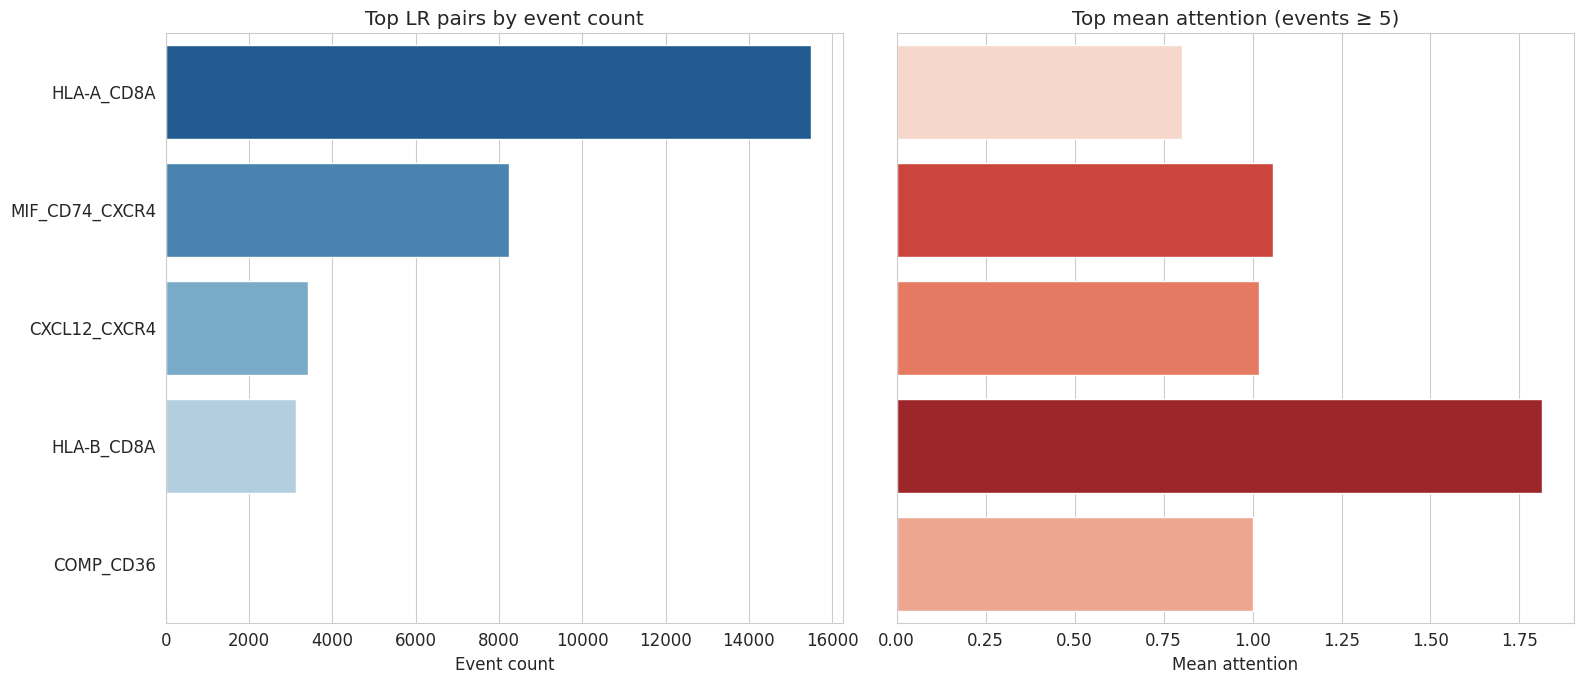

In [4]:
top_lr_n = 15
lr_pair_stats = (
    lr_comm.groupby("lr_pair")
    .agg(
        event_count=("lr_pair", "size"),
        mean_attention=("attention_score", "mean"),
        mean_deg_scaled_attention=("degree_scaled_attention", "mean"),
        mean_score=("original_lr_score", "mean"),
    )
    .sort_values("event_count", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

sns.barplot(
    data=lr_pair_stats.head(top_lr_n),
    x="event_count",
    y="lr_pair",
    ax=axes[0],
    palette="Blues_r",
)
axes[0].set_title("Top LR pairs by event count")
axes[0].set_xlabel("Event count")
axes[0].set_ylabel("")

high_conf = lr_pair_stats[lr_pair_stats["event_count"] >= 5].nlargest(top_lr_n, "mean_attention")
sns.barplot(
    data=high_conf,
    x="mean_attention",
    y="lr_pair",
    ax=axes[1],
    palette="Reds_r",
)
axes[1].set_title("Top mean attention (events ≥ 5)")
axes[1].set_xlabel("Mean attention")
axes[1].set_ylabel("")

plt.tight_layout()
fig_path = OUTPUT_DIR / "lr_pair_summary.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


## Spots with highest communication degree
Outgoing (source) and incoming (target) event counts per spot. Degree-scaled attention multiplies each edge attention by the source out-degree, so high-degree hubs get up-weighted.


/tmp/ipykernel_27815/1328587815.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=spot_outgoing.index, x=spot_outgoing.values, ax=axes[0], palette="viridis")
/tmp/ipykernel_27815/1328587815.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=spot_incoming.index, x=spot_incoming.values, ax=axes[1], palette="magma")


Saved: results/CID44971/figures/top_spots_in_out.png


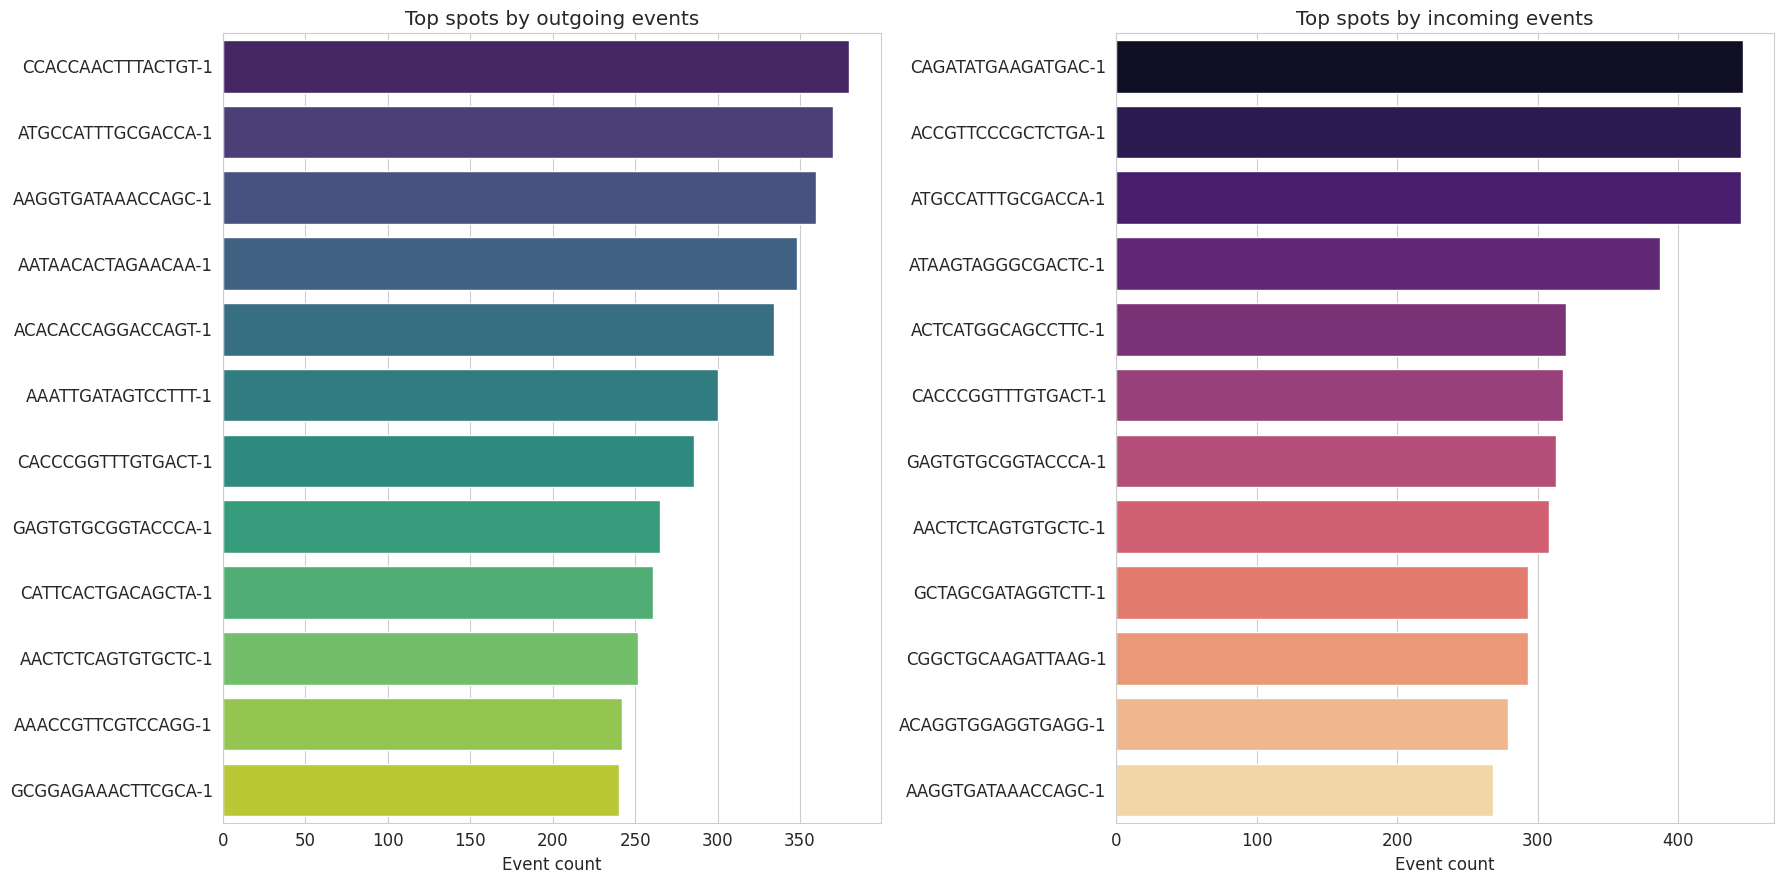

In [5]:
top_spot_n = 12
spot_outgoing = lr_comm.groupby("src_spot_barcode").size().sort_values(ascending=False).head(top_spot_n)
spot_incoming = lr_comm.groupby("dst_spot_barcode").size().sort_values(ascending=False).head(top_spot_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.barplot(y=spot_outgoing.index, x=spot_outgoing.values, ax=axes[0], palette="viridis")
axes[0].set_title("Top spots by outgoing events")
axes[0].set_xlabel("Event count")
axes[0].set_ylabel("")

sns.barplot(y=spot_incoming.index, x=spot_incoming.values, ax=axes[1], palette="magma")
axes[1].set_title("Top spots by incoming events")
axes[1].set_xlabel("Event count")
axes[1].set_ylabel("")

plt.tight_layout()
fig_path = OUTPUT_DIR / "top_spots_in_out.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


## Strongest spot→spot pairs
List and heatmap of spot pairs with the highest event counts.


Top spot→spot pairs:


,src_spot_barcode,dst_spot_barcode,event_count,mean_attention,mean_deg_scaled_attention
140,AAGGTGATAAACCAGC-1,ATGCCATTTGCGACCA-1,99,1.367488,492.295611
576,ATGCCATTTGCGACCA-1,GAGTGTGCGGTACCCA-1,99,1.169691,432.785790
848,CATTCACTGACAGCTA-1,ACCGTTCCCGCTCTGA-1,98,0.800791,209.006326
572,ATGCCATTTGCGACCA-1,AAGGTGATAAACCAGC-1,88,1.380555,510.805388
851,CATTCACTGACAGCTA-1,CGGCTGCAAGATTAAG-1,84,0.786706,205.330393
211,ACACACCAGGACCAGT-1,GAGTGTGCGGTACCCA-1,80,0.783849,261.805587
142,AAGGTGATAAACCAGC-1,CAAGATATTATAACGT-1,78,0.955740,344.066243
49,AAATTTGCGGGTGTGG-1,AAGTTCGGCCAACAGG-1,72,1.095862,191.775855
1153,CGGCTTTGTATGATAA-1,ACAGATTAGGTTAGTG-1,72,0.814492,122.173763
139,AAGGTGATAAACCAGC-1,ACACACCAGGACCAGT-1,70,1.073353,386.407255


Saved: results/CID44971/figures/top_spot_pair_heatmap.png


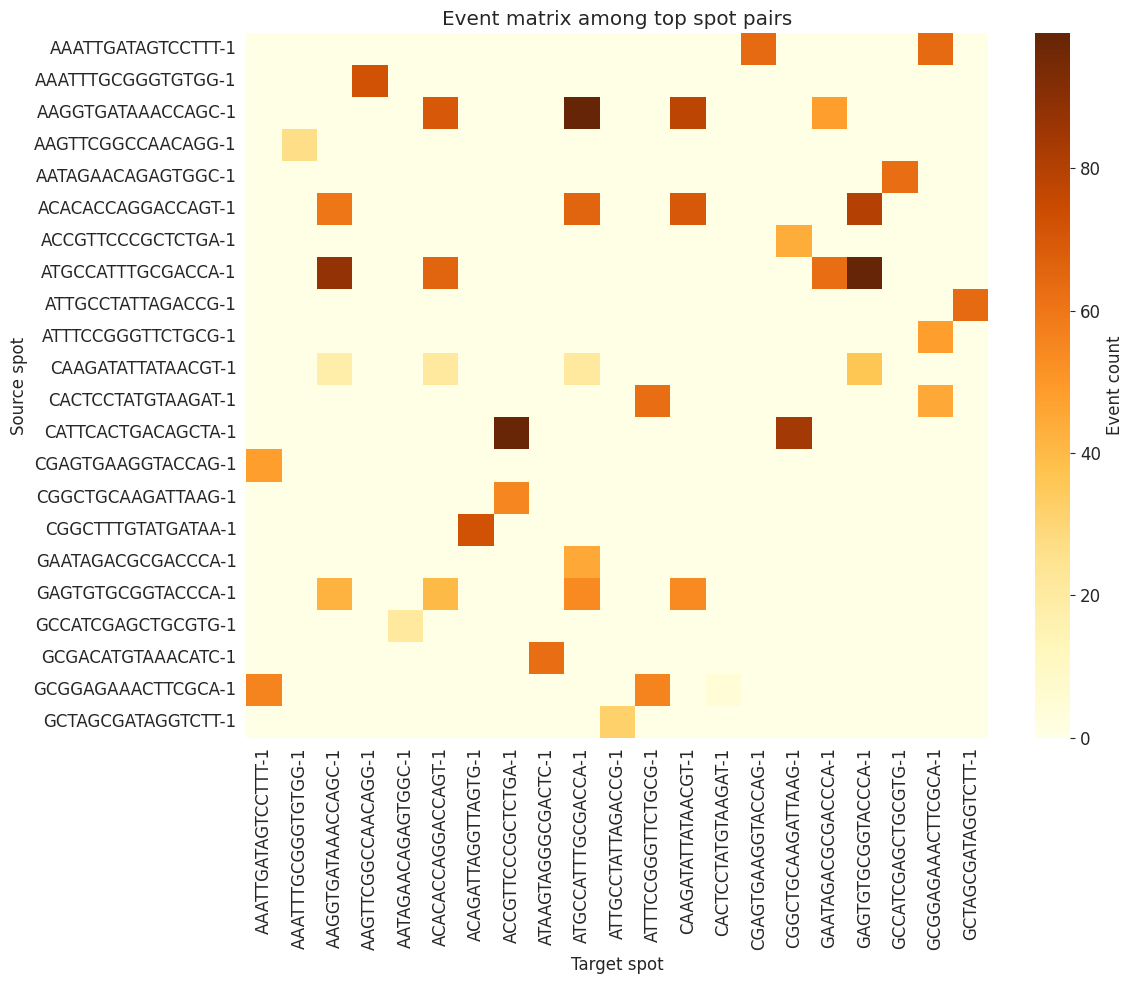

In [6]:
pair_df = (
    lr_comm.groupby(["src_spot_barcode", "dst_spot_barcode"])
    .agg(
        event_count=("lr_pair", "size"),
        mean_attention=("attention_score", "mean"),
        mean_deg_scaled_attention=("degree_scaled_attention", "mean"),
    )
    .reset_index()
)

TopK = 20
top_pairs = pair_df.sort_values("event_count", ascending=False).head(TopK)
print("Top spot→spot pairs:")
display(top_pairs)

focus_spots = pd.unique(top_pairs[["src_spot_barcode", "dst_spot_barcode"]].values.ravel())
heat_df = pair_df[
    pair_df["src_spot_barcode"].isin(focus_spots)
    & pair_df["dst_spot_barcode"].isin(focus_spots)
]
count_matrix = heat_df.pivot(
    index="src_spot_barcode", columns="dst_spot_barcode", values="event_count"
).fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(
    count_matrix,
    annot=False,
    cmap="YlOrBr",
    cbar_kws={"label": "Event count"},
)
plt.title("Event matrix among top spot pairs")
plt.xlabel("Target spot")
plt.ylabel("Source spot")
plt.tight_layout()
fig_path = OUTPUT_DIR / "top_spot_pair_heatmap.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


## Cell-type communication counts
Heatmap for source/target cell types and bar chart for per-type in/out degree.


Saved: results/CID44971/figures/celltype_heatmap.png


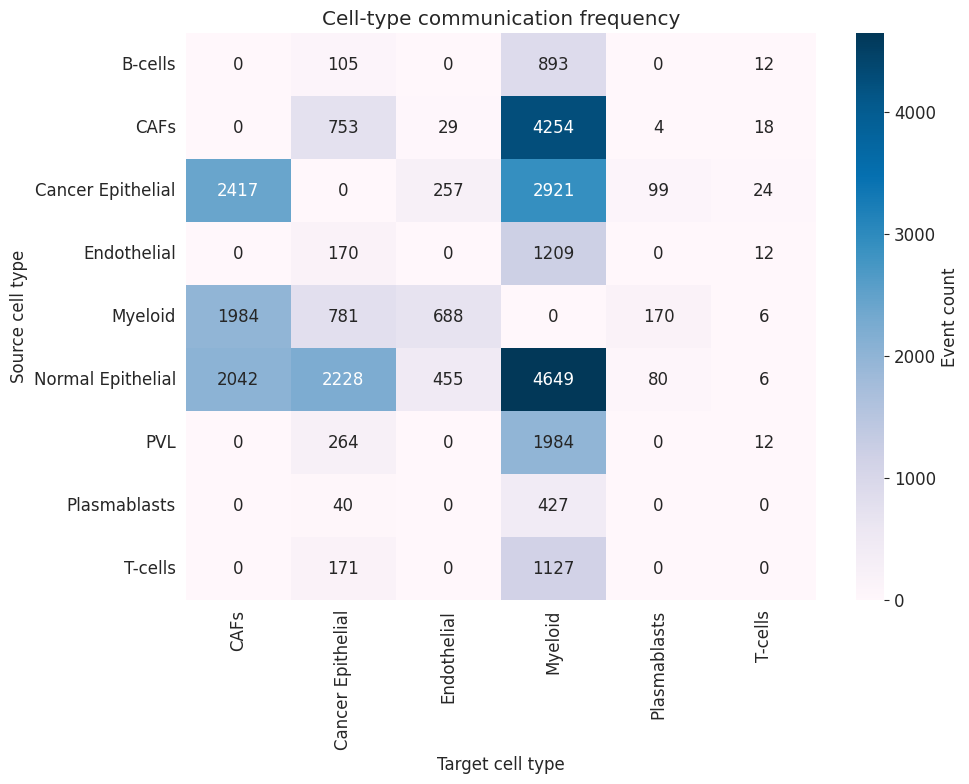

Saved: results/CID44971/figures/celltype_in_out.png


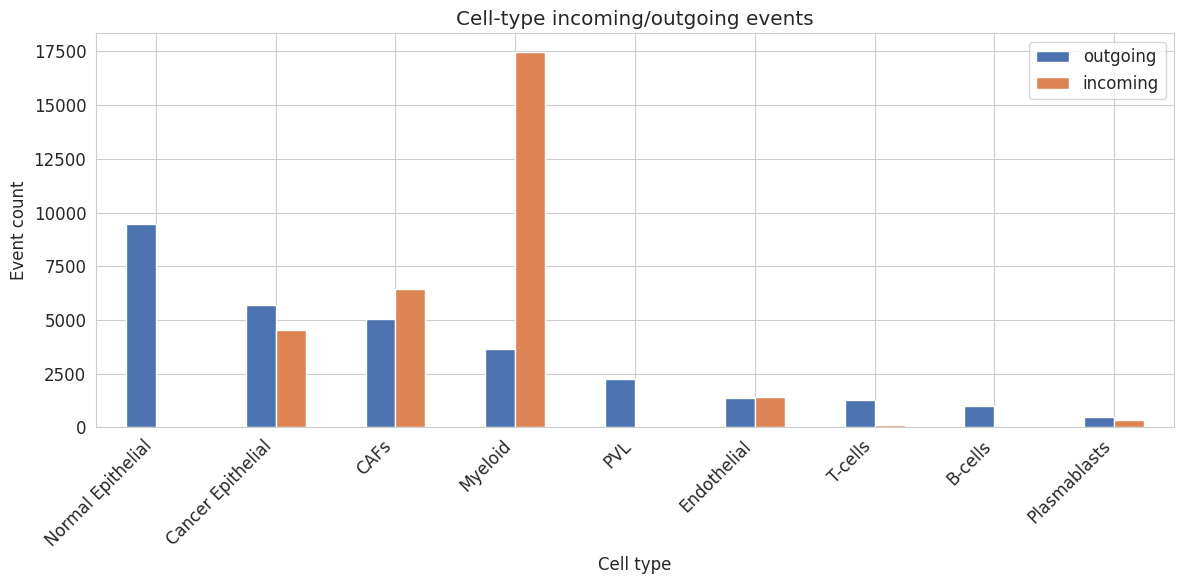

In [7]:
cell_pair_df = (
    lr_comm.groupby(["source_cell", "target_cell"])
    .agg(event_count=("lr_pair", "size"), mean_attention=("attention_score", "mean"))
    .reset_index()
)

cell_matrix = cell_pair_df.pivot(
    index="source_cell", columns="target_cell", values="event_count"
).fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cell_matrix,
    annot=True,
    fmt=".0f",
    cmap="PuBu",
    cbar_kws={"label": "Event count"},
)
plt.title("Cell-type communication frequency")
plt.xlabel("Target cell type")
plt.ylabel("Source cell type")
plt.tight_layout()
fig_path = OUTPUT_DIR / "celltype_heatmap.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

cell_out = lr_comm.groupby("source_cell").size().rename("outgoing")
cell_in = lr_comm.groupby("target_cell").size().rename("incoming")
cell_degree = pd.concat([cell_out, cell_in], axis=1).fillna(0).astype(int)
cell_degree = cell_degree.sort_values("outgoing", ascending=False)

cell_degree.plot(kind="bar", figsize=(12, 6), color=["#4c72b0", "#dd8452"])
plt.title("Cell-type incoming/outgoing events")
plt.xlabel("Cell type")
plt.ylabel("Event count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_path = OUTPUT_DIR / "celltype_in_out.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


## LR pairs around top spots
Focus on the busiest spots (top outgoing or incoming) and show which LR pairs dominate those edges.


Saved: results/CID44971/figures/top_spot_lr_pairs.png


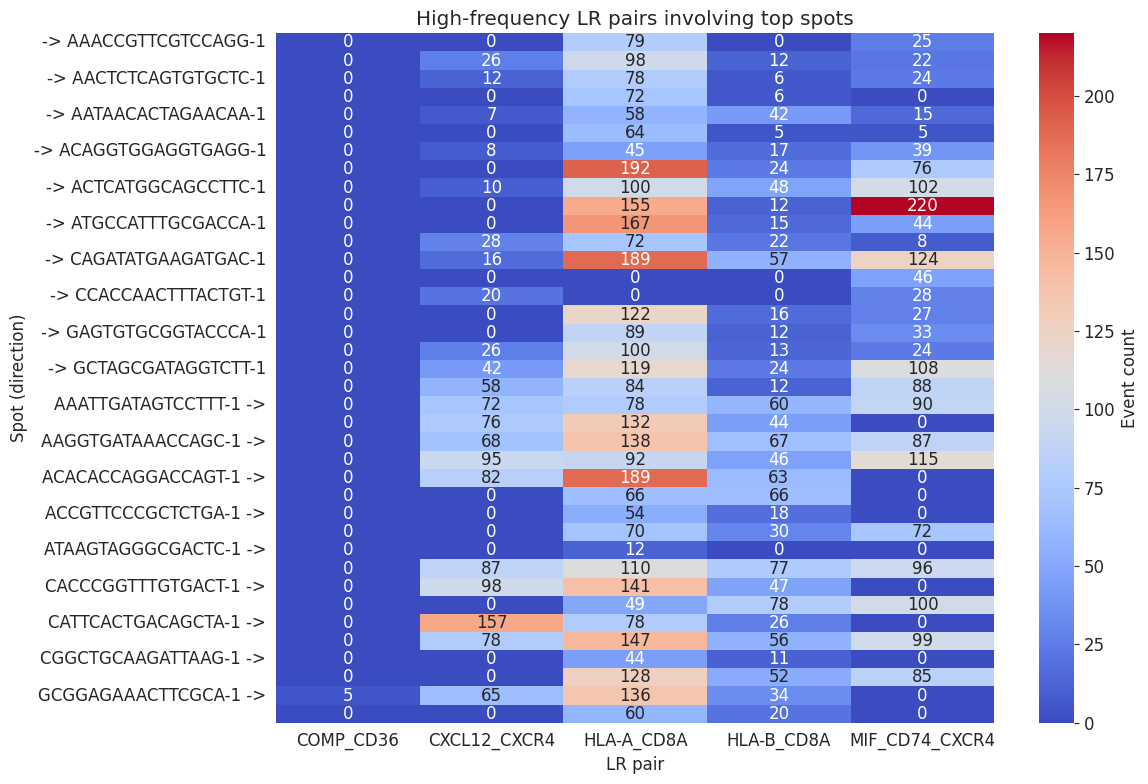

In [8]:
focus_spots = set(spot_outgoing.index) | set(spot_incoming.index)
focus_comm = lr_comm[
    lr_comm["src_spot_barcode"].isin(focus_spots)
    | lr_comm["dst_spot_barcode"].isin(focus_spots)
].copy()

# Role label for readability
def choose_role(row):
    if row["src_spot_barcode"] in focus_spots:
        return f"{row['src_spot_barcode']} ->"
    elif row["dst_spot_barcode"] in focus_spots:
        return f"-> {row['dst_spot_barcode']}"
    return "other"

focus_comm["spot_role"] = focus_comm.apply(choose_role, axis=1)
focus_comm = focus_comm[focus_comm["spot_role"] != "other"]

hot_lr_pairs = focus_comm["lr_pair"].value_counts().head(10).index
heat_input = focus_comm[focus_comm["lr_pair"].isin(hot_lr_pairs)]
spot_lr_matrix = heat_input.pivot_table(
    index="spot_role", columns="lr_pair", values="attention_score", aggfunc="count", fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    spot_lr_matrix,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    cbar_kws={"label": "Event count"},
)
plt.title("High-frequency LR pairs involving top spots")
plt.xlabel("LR pair")
plt.ylabel("Spot (direction)")
plt.tight_layout()
fig_path = OUTPUT_DIR / "top_spot_lr_pairs.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


## Optional spatial overlay for key spots
Set `enable_spatial_overlay = True` and provide `st_h5ad_path` (must contain `obsm['spatial']`). The cell will plot top-degree spots and arrows for the strongest spot pairs.


Saved: results/CID44971/figures/top_pairs_spatial.png


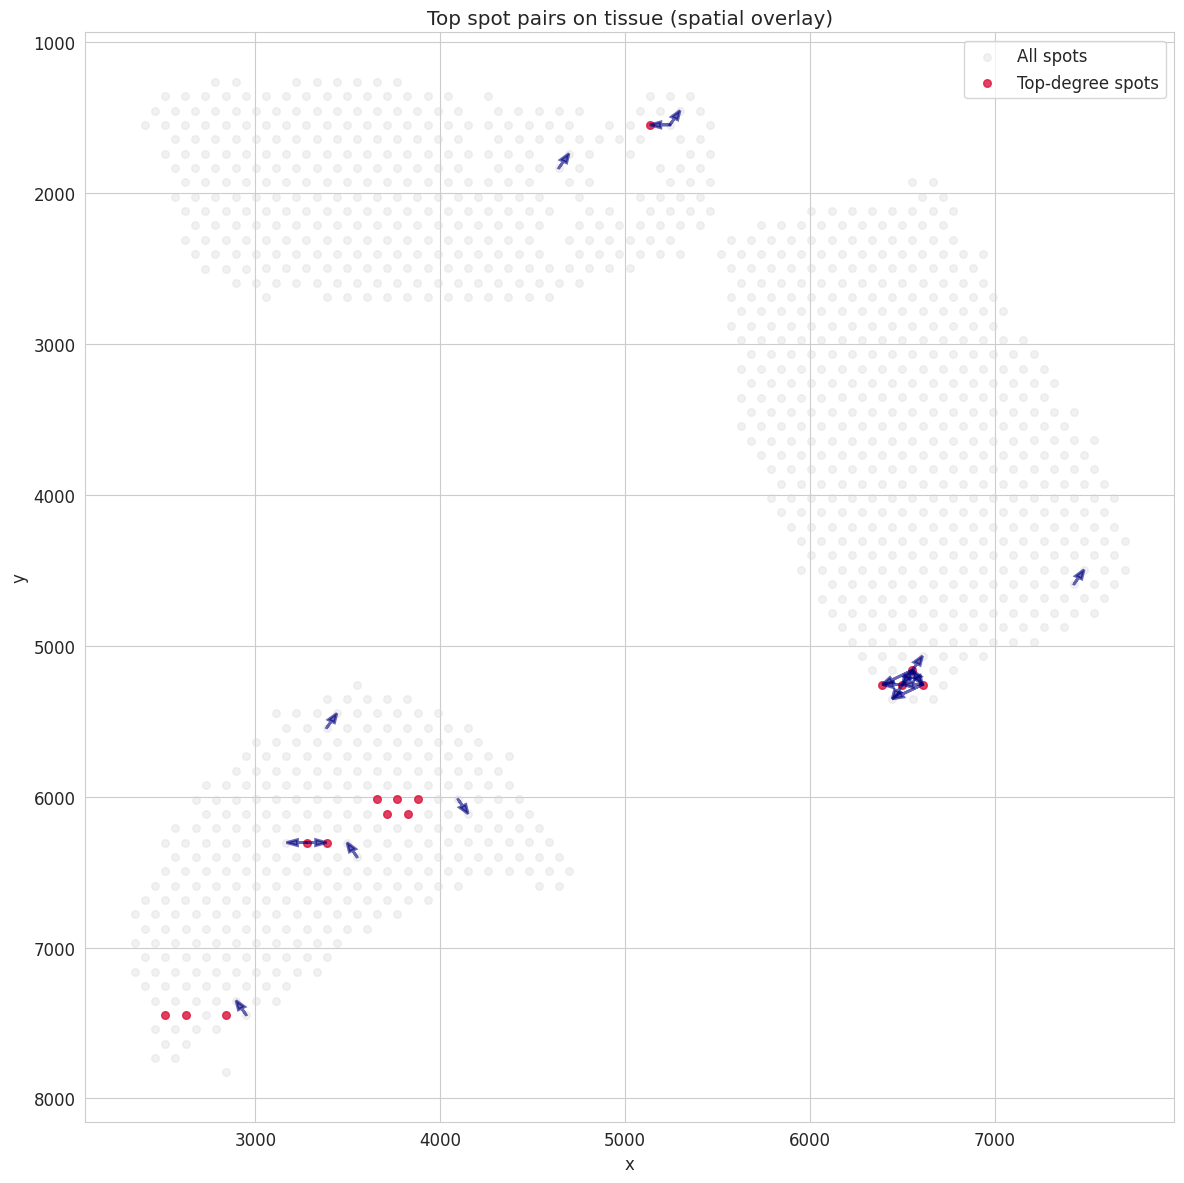

In [9]:
from pathlib import Path

enable_spatial_overlay = True  # set to True when you have the h5ad file and scanpy installed
st_h5ad_path = Path("../ST_Graduation_Project_data/database/Wu/CID44971/CID44971_ST.h5ad")

if enable_spatial_overlay and st_h5ad_path.exists():
    import scanpy as sc
    adata = sc.read_h5ad(st_h5ad_path)
    coords = pd.DataFrame(adata.obsm["spatial"], index=adata.obs_names, columns=["x", "y"])

    # Rank spots by total degree (in + out)
    deg_out = lr_comm.groupby("src_spot_barcode").size().rename("out")
    deg_in = lr_comm.groupby("dst_spot_barcode").size().rename("in")
    deg = pd.concat([deg_out, deg_in], axis=1).fillna(0)
    deg["total"] = deg["out"] + deg["in"]
    top_spots = deg.sort_values("total", ascending=False).head(15)

    # Arrows for top spot pairs (by event count)
    arrows = top_pairs.copy()
    arrows["src_x"] = arrows["src_spot_barcode"].map(coords["x"])
    arrows["src_y"] = arrows["src_spot_barcode"].map(coords["y"])
    arrows["dst_x"] = arrows["dst_spot_barcode"].map(coords["x"])
    arrows["dst_y"] = arrows["dst_spot_barcode"].map(coords["y"])
    arrows = arrows.dropna(subset=["src_x", "src_y", "dst_x", "dst_y"])

    plt.figure(figsize=(12, 12))
    plt.scatter(coords["x"], coords["y"], s=30, c="lightgray", alpha=0.3, label="All spots")

    # Highlight top spots by total degree
    plt.scatter(
        coords.loc[top_spots.index, "x"],
        coords.loc[top_spots.index, "y"],
        s=30,
        c="crimson",
        alpha=0.8,
        label="Top-degree spots",
    )

    for _, row in arrows.iterrows():
        plt.arrow(
            row.src_x,
            row.src_y,
            row.dst_x - row.src_x,
            row.dst_y - row.src_y,
            color="navy",
            alpha=0.6,
            linewidth=2,
            length_includes_head=True,
            head_width=40,
        )

    plt.gca().invert_yaxis()  # common for Visium coordinates
    plt.legend()
    plt.title("Top spot pairs on tissue (spatial overlay)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "top_pairs_spatial.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("Spatial overlay disabled (set enable_spatial_overlay=True and provide the h5ad path to enable).")


## Ligand/Receptor expression across cell types (optional)
If `spot_cell_full_expr.csv` exists, this cell summarizes mean expression of top ligands and receptor subunits by cell type (cell type parsed from the suffix of `spot_cell`).


Saved: results/CID44971/figures/ligand_expression_heatmap.png


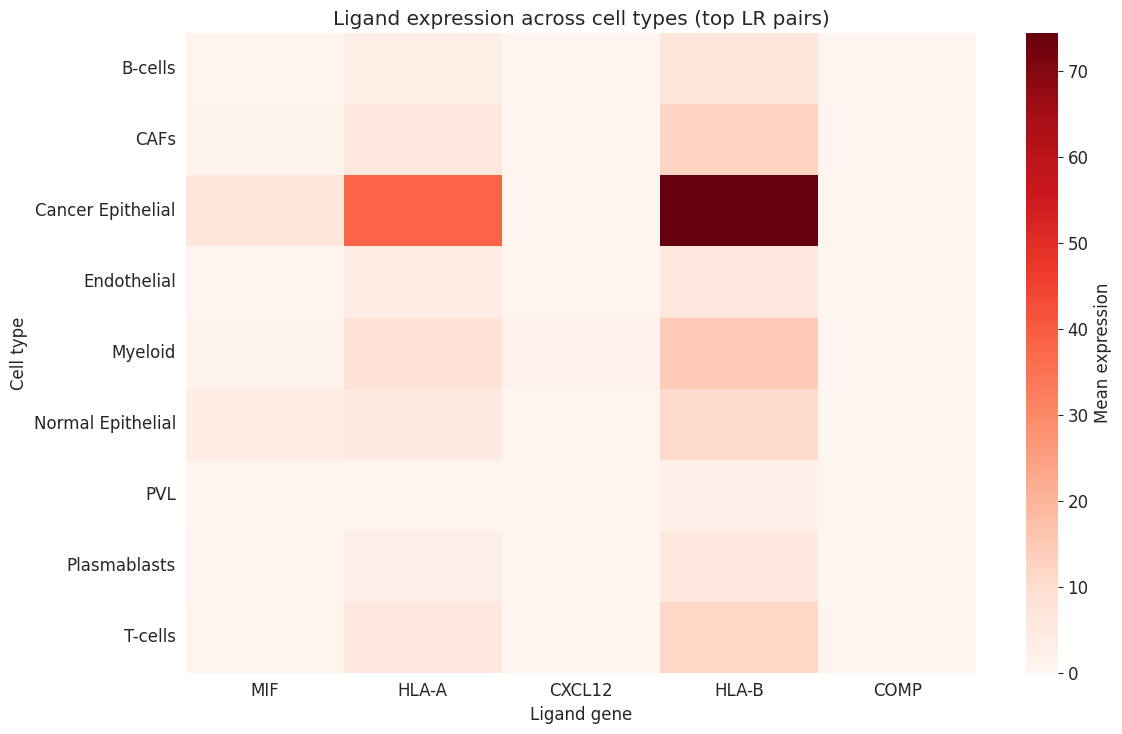

Saved: results/CID44971/figures/receptor_expression_heatmap.png


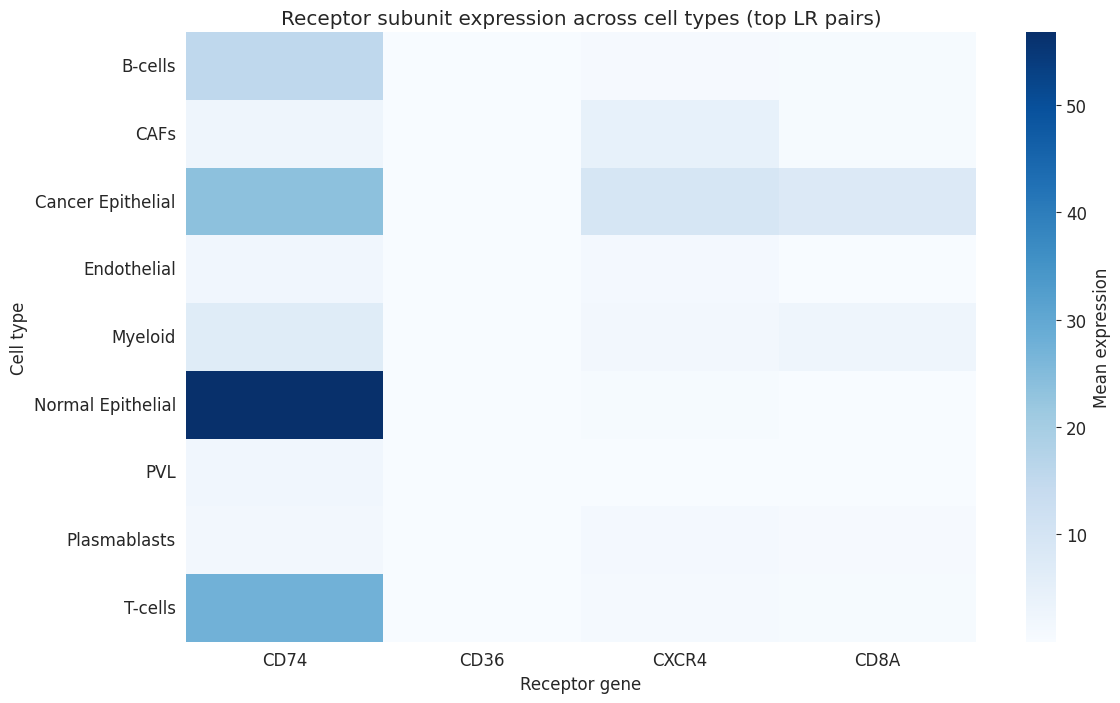

In [10]:
if expr_path.exists():
    expr_df = pd.read_csv(expr_path)
    # Derive cell type from the suffix after the last underscore
    expr_df["cell_type"] = expr_df["spot_cell"].apply(lambda x: str(x).rsplit("_", 1)[-1])

    # Top LR pairs by event count
    top_pairs_for_expr = lr_comm["lr_pair"].value_counts().head(12).index
    ligands = lr_comm[lr_comm["lr_pair"].isin(top_pairs_for_expr)]["lr_ligand"].unique()
    receptor_genes = set()
    for rec_combo in lr_comm[lr_comm["lr_pair"].isin(top_pairs_for_expr)]["lr_receptor_combined"].dropna():
        receptor_genes.update(rec_combo.split("_"))
    ligands = [g for g in ligands if g in expr_df.columns]
    receptor_genes = [g for g in receptor_genes if g in expr_df.columns]

    ligand_expr = expr_df.groupby("cell_type")[ligands].mean().sort_index()
    receptor_expr = expr_df.groupby("cell_type")[receptor_genes].mean().sort_index()

    plt.figure(figsize=(12, 6 + 0.3 * len(ligands)))
    sns.heatmap(ligand_expr, cmap="Reds", cbar_kws={"label": "Mean expression"})
    plt.title("Ligand expression across cell types (top LR pairs)")
    plt.xlabel("Ligand gene")
    plt.ylabel("Cell type")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "ligand_expression_heatmap.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

    plt.figure(figsize=(12, 6 + 0.3 * len(receptor_genes)))
    sns.heatmap(receptor_expr, cmap="Blues", cbar_kws={"label": "Mean expression"})
    plt.title("Receptor subunit expression across cell types (top LR pairs)")
    plt.xlabel("Receptor gene")
    plt.ylabel("Cell type")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "receptor_expression_heatmap.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("Expression file not found; skipping ligand/receptor expression heatmaps.")


## Top 5 ligands/receptors spatial expression
Plot the top-5 ligands and receptors (by event count) on the tissue slice. Receptor combos are averaged across available subunits.


In [12]:
import numpy as np
enable_spatial_expr = True
spatial_expr_h5ad = st_h5ad_path  # reuse path above

if enable_spatial_expr and spatial_expr_h5ad.exists():
    if "lr_ligand" not in lr_comm.columns:
        lr_comm[["lr_ligand", "lr_receptor_combined"]] = lr_comm["lr_pair"].str.split("_", n=1, expand=True)

    top_ligands = lr_comm["lr_ligand"].value_counts().head(5).index.tolist()
    top_receptors = lr_comm["lr_receptor_combined"].value_counts().head(5).index.tolist()

    if "adata" not in locals():
        import scanpy as sc
        adata = sc.read_h5ad(spatial_expr_h5ad)
    coords = np.array(adata.obsm["spatial"])

    def fetch_expr(gene):
        if gene not in adata.var_names:
            return None
        expr = adata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray()
        return np.ravel(expr)

    def plot_gene(gene, expr_vals, kind):
        if expr_vals is None:
            print(f"[{kind}] skip {gene}: not found")
            return
        plt.figure(figsize=(6, 5))
        plt.scatter(coords[:, 0], coords[:, 1], c=expr_vals, cmap="viridis", s=10, linewidth=0)
        plt.colorbar(label="expression")
        plt.title(f"{kind}: {gene}")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        out_path = OUTPUT_DIR / f"spatial_{kind}_{gene}.png"
        plt.savefig(out_path, dpi=200)
        plt.close()
        print("Saved", out_path)

    for lg in top_ligands:
        plot_gene(lg, fetch_expr(lg), "ligand")

    for rc in top_receptors:
        parts = [p for p in str(rc).split("_") if p]
        expr_list = []
        for p in parts:
            val = fetch_expr(p)
            if val is not None:
                expr_list.append(val)
        avg_expr = np.mean(expr_list, axis=0) if expr_list else None
        plot_gene(rc.replace("_", "+"), avg_expr, "receptor")
else:
    print("Spatial h5ad not found or disabled; skip spatial expression maps.")


Saved results/CID44971/figures/spatial_ligand_HLA-A.png
Saved results/CID44971/figures/spatial_ligand_MIF.png
Saved results/CID44971/figures/spatial_ligand_CXCL12.png
Saved results/CID44971/figures/spatial_ligand_HLA-B.png
Saved results/CID44971/figures/spatial_ligand_COMP.png
Saved results/CID44971/figures/spatial_receptor_CD8A.png
Saved results/CID44971/figures/spatial_receptor_CD74+CXCR4.png
Saved results/CID44971/figures/spatial_receptor_CXCR4.png
Saved results/CID44971/figures/spatial_receptor_CD36.png
